<figure style="text-align: center;">
  <img src="_static/intro/title_page.png" style="display: block; margin: 0 auto; width: 100%;">
</figure>

### Object-based Simulation

Michael J. Pyrcz, Professor, The University of Texas at Austin 

[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

Chapter of e-book "Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy". 

```{admonition} Cite this e-Book as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy* [e-book]. Zenodo. doi:10.5281/zenodo.15169133 [![DOI](https://zenodo.org/badge/838927017.svg)](https://doi.org/10.5281/zenodo.15169132)  
```

The workflows in this book and more are available here:

```{admonition} Cite the GeostatsPyDemos GitHub Repository as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *GeostatsPyDemos: GeostatsPy Python Package for Spatial Data Analytics and Geostatistics Demonstration Workflows Repository* (0.0.1) [Software]. Zenodo. doi:10.5281/zenodo.12667036. GitHub Repository: https://github.com/GeostatsGuy/GeostatsPyDemos [![DOI](https://zenodo.org/badge/777871341.svg)](https://doi.org/10.5281/zenodo.12667035)



```

By Michael J. Pyrcz <br />
&copy; Copyright 2024.

This chapter is a tutorial for / demonstration of  **Object-based Simulation** for simulating spatial categorical features, e.g., like facies. 

* specifically, we use object-based simulation to simulate categorical features and to produce models with heterogeneities more complicated than variogram-based methods, and when the required reproduction of geometries not possible with multiple point simulation.

**YouTube Lecture**: check out my lectures on:

* TBD

For your convenience here's a summary of salient points for object-based simulation,

* simulation models based on stochastic placement of parameterized geometries based on observations from outcrops and seismic data.

Additional details for advanced learning,

#### Objects-based and Geological Shapes

Many subsurface geological resources exhibit distinctive geometries that arise from depositional and preservation processes. Rather than occurring as random distributions, geological facies are often organized into recognizable shapes and bodies.

For example,

* Fluvial systems deposit sediment within channels that commonly have concave-upward geometries, while overbank flooding forms levees with characteristic gull-wing cross-sectional shapes.

* Low-energy lacustrine environments deposit laterally extensive, thin sheets of mud.

* Deep-water turbidity currents create stacked sandy lobes separated by shaly hemipelagic deposits.

<figure style="text-align: center;">
  <img src="_static/object/outcrop.png" style="display: block; margin: 0 auto; width: 50%;">
  <figcaption style="text-align: center;"> Outcrop with interpreted channels (Birgenheier, L, , 2019).
</figcaption>
</figure>

Object-based simulation takes advantage of these naturally occurring geological geometries. Instead of simulating facies one grid cell at a time, we work with groups of cells defined by parameterized geological objects. These objects are designed to represent the shapes observed in nature while allowing variability through a set of geometric parameters.

Some example parameterizations are shown below.

<figure style="text-align: center;">
  <img src="_static/object/parameters.png" style="display: block; margin: 0 auto; width: 80%;">
  <figcaption style="text-align: center;"> Example geometric parameterizations (Pyrcz and Deutsch, 2014).
</figcaption>
</figure>

The examples above illustrate channels and lobes whose geometries can be controlled through parameters such as:

* Width

* Height, depth, or thickness

* Sinuosity

* Roughness

* Orientation

For an example parameterization with associated function, consider the plan view lobel model from Pyrcz and Deutch (2014),

$$
y=
\begin{cases}
w + 4(W-w)\frac{x}{2l}\left(1-\frac{x}{2l}\right), & 0\le x\le l \\
W\sqrt{1-\frac{x-l}{L-l}}, & l\le x\le L
\end{cases}
$$

where $x$ is the distance down dip, $y$ is the distance orthogonal to dip from the centerline, $l$ and $L$ are the length to widest and terminus respectively, while $w$ and $W$ are the width at the proximal edge ($x=0$) and maximum width respectively.

and the labelled planview, long section and cross section for the parameterized lobe geometry,

<figure style="text-align: center;">
  <img src="_static/object/lobe_parameters.png" style="display: block; margin: 0 auto; width: 60%;">
  <figcaption style="text-align: center;"> Example parameerized lobe geometry (Pyrcz and Deutsch, 2014).
</figcaption>
</figure>

The details of this equation are not important, but it serves as an example of creating a function with a few, intuitive parameters to represent commonly oberved shapes from geology. 

Although channels and lobes are among the most common applications, object-based simulation is not limited to these geometries. Any geological body that can be represented by a parameterized shape may be incorporated into an object-based modeling workflow.

The general object-based simulation workflow is straightforward,

1. Initialize the model with the background facies.

2. Randomly place an object within the model. All grid cells falling inside the object's geometry are assigned the object's facies.

3. Repeat the placement process until a target facies proportion, object count, or stopping criterion is reached.

By repeatedly placing stochastic objects, we generate realizations that honor both the geological geometries and their associated uncertainty.

To build intuition, we will begin with the simplest form of object-based modeling: binary categorical simulation in a small two-dimensional model. From this foundation, we will progressively add more realistic geological complexity.

#### Load the Required libraries

The following code loads the required libraries. 

In [1]:
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization and wrapper
import geostatspy.geostats as geostats                        # GSLIB methods convert to Python      
import geostatspy
print('GeostatsPy version: ' + str(geostatspy.__version__))  

GeostatsPy version: 0.0.71


We will also need some standard packages. These should have been installed with Anaconda 3.

In [2]:
import os                                                     # set working directory, run executables

from tqdm import tqdm                                         # suppress the status bar
from functools import partialmethod
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)

ignore_warnings = True                                        # ignore warnings?
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
import matplotlib.pyplot as plt                               # for plotting
import matplotlib.patches as patches
from matplotlib.patches import Rectangle    
import matplotlib as mpl                                      # custom colorbar
import matplotlib.patches as mpatches                         # categorical legend
import matplotlib.ticker as mticker                           # axes ticks

from matplotlib.colors import LinearSegmentedColormap         
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
plt.rc('axes', axisbelow=True)                                # plot all grids below the plot elements
if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')
cmap = plt.cm.inferno                                         # color map
seed = 42

If you get a package import error, you may have to first install some of these packages. This can usually be accomplished by opening up a command window on Windows and then typing 'python -m pip install [package-name]'. More assistance is available with the respective package docs. 

#### Define Functions

These are the fundamental functions required to calculate a object-based realization, including,

* **add_channel** - place a single channel in the grid, append to grid
  
* **generate_channel_well_data** - generate stochastic channelized model, extract well log

* **build_well_as_full_grid** - convert a single well column into a full grid

* **generate_model** - unconditional object-based channel realization

* **violates_well** - check if new channel overlaps well

* **find_valid_x** - abjust the channel to fit the well

* **get_sand_cells** - get sand intervals in the grid

* **generate_conditional_model** - conditional object-based channel realization

* **add_grid** - add grid lines to plot

* **add_grid2** - add grid lines to plot

* **add_model_grid** - add grid lines to plot

* **add_custom_sand_shale_legend** - custom sand and shale legend

* **plot_channel_centroids** - plot points at the centers of all channel cells

* **plot_channel_outline** - plot the top and bottom channel boundaries.

In [3]:
def add_channel(grid, ix, iy, half_width, thickness, p=4):    # place a single channel in the grid, append to grid
    ny, nx = grid.shape
    x_min = max(ix - half_width, 0)
    x_max = min(ix + half_width + 1, nx)
    for x in range(x_min, x_max):
        dx = x - ix
        x_norm = np.abs(dx) / max(half_width, 1)
        local_thickness = thickness * (1.0 - x_norm**p)       # channel thickness at this x location
        local_thickness = max(0.0, local_thickness)
        y_bottom = iy + int(np.round(local_thickness))
        y0 = max(iy, 0); y1 = min(y_bottom + 1, ny)
        grid[y0:y1, x] = 1
    return grid

def generate_channel_well_data(nx,ny,xsiz,ysiz,ix,CHprop=0.2,thickness_range=(3, 10), # generate stochastic channelized model, extract well log
    half_width_range=(3, 8),max_attempts=5000,seed=None):
    if seed is not None:
        np.random.seed(seed)
    grid = np.zeros((ny, nx), dtype=int)
    target_cells = int(CHprop * nx * ny)
    current_cells = 0
    attempts = 0

    while current_cells < target_cells and attempts < max_attempts: # random channel geometry
        half_width = np.random.randint(*half_width_range)
        thickness = np.random.randint(*thickness_range)
        ix_c = np.random.randint(half_width, nx - half_width)
        iy_c = np.random.randint(0, ny - thickness)  
        before = grid.sum()                                   # temporary grid copy to measure increment

        grid = add_channel(grid,ix=ix_c,iy=iy_c,half_width=half_width,thickness=thickness)  # add channel
        after = grid.sum()
        current_cells = after
        attempts += 1
 
    well_log = grid[:, ix].copy()                             # extract well
    mask = np.ones_like(well_log, dtype=bool)
    return grid, well_log, mask

def build_well_as_full_grid(grid, ix):                        # convert a single well column into a full grid
    ny, nx = grid.shape
    well_grid = np.full((ny, nx), np.nan)                     # initialize with NaN 
    well_grid[:, ix] = grid[:, ix]                            # insert observed well column
    return well_grid

def generate_model(nx, ny,CHprop,CHwidth,CHthick,seed=42,p=4,): # unconditional object-based channel realization
    np.random.seed(seed)
    grid = np.zeros((ny, nx), dtype=int)
    target_cells = int(CHprop * nx * ny)
    width_mu, width_sigma = CHwidth
    thick_mu, thick_sigma = CHthick
    while grid.sum() < target_cells:
        half_width = int(np.round(np.random.normal(width_mu, width_sigma))) # Gaussian sampling (continuous → discrete)
        thickness  = int(np.round(np.random.normal(thick_mu, thick_sigma)))
        half_width = max(1, half_width)                       # enforce physical constraints
        thickness  = max(1, thickness)
        ix_c = np.random.randint(0, nx)
        iy_c = np.random.randint(0, ny)
        grid = add_channel(grid, ix_c, iy_c, half_width, thickness,p)
    return grid

def violates_well(ix, iy, half_width, thickness, well_grid, model_shape): # check if new channel overlaps well
    ny, nx = model_shape
    temp = np.zeros((ny, nx), dtype=int)
    temp = add_channel(temp, ix, iy, half_width, thickness)
    return np.any((temp == 1) & (well_grid == 0))             # reject if overlaps shale in observed well

def find_valid_x(ix, iy, half_width, thickness, well_grid, model_shape, max_shift=10): # abjust the channel to fit the well
    if not violates_well(ix, iy, half_width, thickness, well_grid, model_shape): # try original
        return ix
    for d in range(1, max_shift + 1):
        if ix - d >= 0:
            if not violates_well(ix - d, iy, half_width, thickness, well_grid, model_shape):
                return ix - d
        if ix + d < model_shape[1]:
            if not violates_well(ix + d, iy, half_width, thickness, well_grid, model_shape):
                return ix + d
    return None

def get_sand_cells(well_grid):                                # get sand intervals in the grid
    return np.argwhere(well_grid == 1)

def generate_conditional_model(nx,ny,CHprop,CHwidth,CHthick,well_grid,ix_well,seed=42,max_iter=20000):
    np.random.seed(seed)
    model = np.zeros((ny, nx), dtype=int)
    width_mu, width_sigma = CHwidth
    thick_mu, thick_sigma = CHthick
    sand_cells = get_sand_cells(well_grid)

    uncovered = set([(y, x) for (y, x) in sand_cells])        # step 1, hard data conditioning sand intervals at wells
    it = 0
    while len(uncovered) > 0 and it < max_iter:
        y_target, x_target = list(uncovered)[np.random.randint(len(uncovered))]
        half_width = max(1, int(np.round(np.random.normal(width_mu, width_sigma))))
        thickness  = max(1, int(np.round(np.random.normal(thick_mu, thick_sigma))))    
        iy = y_target                                         # anchor vertically in sand interval
        ix = find_valid_x(x_target,iy,half_width,thickness,well_grid,model.shape)   # try horizontal adjustment
        if ix is not None:
            model = add_channel(model, ix, iy, half_width, thickness)
            for (yy, xx) in list(uncovered):                  # update coverage (remove any sand cells now covered)
                if model[yy, xx] == 1:
                    uncovered.remove((yy, xx))
        it += 1
    if len(uncovered) > 0:                                    # safety check
        print("WARNING: not all sand cells were conditioned")
    target_cells = int(CHprop * nx * ny)                      # step 2, fill away from wells
    it = 0
    while model.sum() < target_cells and it < max_iter:
        half_width = max(1, int(np.round(np.random.normal(width_mu, width_sigma))))
        thickness  = max(1, int(np.round(np.random.normal(thick_mu, thick_sigma))))
        ix = np.random.randint(0, nx)
        iy = np.random.randint(0, ny)
        temp = np.zeros_like(model)
        temp = add_channel(temp, ix, iy, half_width, thickness)
        if np.any((temp == 1) & (~np.isnan(well_grid))):      # reject ANY overlap with observed well
            it += 1
            continue
        model = np.maximum(model, temp)
        it += 1
    return model
  
def add_grid():                                               # add grid lines to plot
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks 

def add_grid2(sub_plot):
    sub_plot.grid(True, which='major',linewidth = 1.0); sub_plot.grid(True, which='minor',linewidth = 0.2) # add y grids
    sub_plot.tick_params(which='major',length=7); sub_plot.tick_params(which='minor', length=4)
    sub_plot.xaxis.set_minor_locator(AutoMinorLocator()); sub_plot.yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks

def add_model_grid(ax):
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5 * xsiz))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5 * ysiz))

    ax.xaxis.set_minor_locator(mticker.MultipleLocator(xsiz))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(ysiz))

    ax.grid(which='minor', color='black', linewidth=0.3, alpha=0.25)
    ax.grid(which='major', color='black', linewidth=0.8, alpha=0.5)

    ax.tick_params(which='minor', length=0)                   # hide minor tick marks
    ax.tick_params(which='major', labelsize=8)

def add_custom_sand_shale_legend(ax):                         # custom sand and shale legend
    ax.add_patch(Rectangle((0.81, 0.015), 0.18, 0.18,transform=ax.transAxes,  # white background box
        facecolor='white',edgecolor='black',zorder=20))
    ax.add_patch(Rectangle((0.83, 0.12), 0.05, 0.04,transform=ax.transAxes, # sand
        facecolor='gold',edgecolor='black',zorder=21))
    ax.text(0.90, 0.13,'Sand',transform=ax.transAxes,va='center',fontsize=8,zorder=21)
    ax.add_patch(Rectangle((0.83, 0.05), 0.05, 0.04,transform=ax.transAxes, # shale
        facecolor='grey',edgecolor='black',zorder=21))
    ax.text(0.90, 0.06,'Shale',transform=ax.transAxes,va='center',fontsize=8,zorder=21)

def plot_channel_centroids(ax, grid, xmn, ymn, xsiz, ysiz, **kwargs): # plot points at the centers of all channel cells
    iy, ix = np.where(grid == 1)
    x = xmn + (ix) * xsiz
    y = ymn + (iy) * ysiz
    ax.scatter(x, y, **kwargs)
    return x, y

def plot_channel_outline(ax, ix, iy, half_width, thickness,xmn, ymn, xsiz, ysiz,p=4, **kwargs): # plot the top and bottom channel boundaries.
    x = np.arange(max(ix-half_width, 0),ix+half_width+1)
    dx = x - ix
    x_norm = np.abs(dx) / max(half_width, 1)
    local_thickness = thickness * (1.0 - x_norm**p)
    x_plot = xmn + (x) * xsiz
    y_top = ymn + (iy-0.5) * ysiz
    y_bot = ymn + (iy + local_thickness + 0.5) * ysiz
    ax.plot(x_plot, np.full_like(x_plot, y_top),**kwargs)
    ax.plot(x_plot, y_bot,**kwargs)

#### Make Custom Colorbar

We make these colorbars to display our,

* categorical binary spatial feature, sand and shale facies.

* continuous proportion of channel over many realizations

In [4]:
cmap_facies = mpl.colors.ListedColormap(['grey','gold'])      # sand and shale binary color map
cmap_facies.set_over('white'); cmap_facies.set_under('white')
cmap_facies_cont = LinearSegmentedColormap.from_list("cmap_facies_cont",["grey", "gold"],) # continuous color map variant

#### Set the Working Directory

I always like to do this so I don't lose files and to simplify subsequent read and writes (avoid including the full address each time). 

In [5]:
#os.chdir("c:/PGE383")                                        # set the working directory

#### Set Up Model Grid

For our demonstration, we apply a small 2D regular grid model with,

* $n_x = 60$, $n_y = 40$

Given the model cells sizes,

* $siz_{x} = 10.0$ m, $siz_{y} = 1.0$ m

This results in model extents of,

* $extents_{x} = 600$ m, and $extents_{y}$ = 40 m

This provides sufficient resolution and area of interest to represent our stacked sand filled channels with fast object-based simulation runs. 

Then we initialize the model grid with a background facies,

* for our channel object-based model, the background facies is out of channel shales 

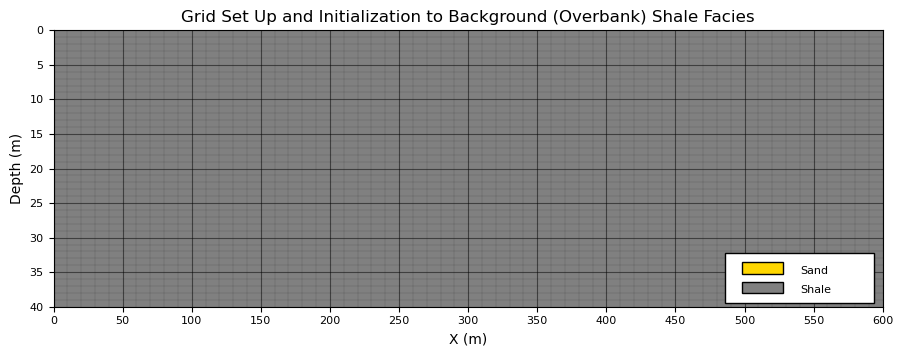

In [6]:
nx, ny = 60, 40                                               # number of grid cells
xsiz = 10.0; ysiz = 1.0                                       # grid cell sizes, in GSLIB GeoDAS format, i.e., cell center, regular grid
xmn = xsiz * 0.5; ymn = ysiz * 0.5                            # origin at center of first cell, lower left corner, GSLIB convention
x = xmn + np.arange(nx) * xsiz; y = ymn + np.arange(ny) * ysiz # cell centers as x and y coordinate vectors
xmin = xmn - xsiz*0.5; ymin = ymn - ysiz*0.5                  # grid extents
xmax = xmin + nx * xsiz; ymax = ymin + ny * ysiz
extents = [xmin,xmax,ymax,ymin]

grid = np.zeros((ny, nx), dtype=int)                          # initialize facies grid (0 = overbank, 1 = channel) with shale only
fig = plt.figure(figsize=(10.7, 4)); ax = plt.gca()           # plot specs
add_model_grid(ax); add_custom_sand_shale_legend(ax)          # custom grid and legend
plt.imshow(grid,interpolation = None,aspect=5.0,cmap=cmap_facies_cont,extent=extents)  # plot model

plt.title("Grid Set Up and Initialization to Background (Overbank) Shale Facies"); plt.xlabel("X (m)"); plt.ylabel("Depth (m)"); plt.show()

#### Parameterized Channel Objects

To efficiently represent channelized depositional systems, we use a simple parameterized channel cross-section model based on a parabolic–power law formulation. 

* the objective is not to reproduce every detail of natural channels, but rather to capture their primary geometric characteristics with a small number of intuitive parameters.

The channel is represented as a binary function on a discrete simulation grid,

$$
g(x,y) \in {0,1},
$$

where $g(x,y)=1$ indicates channel facies (sand), and $g(x,y)=0$ indicates background facies (shale). First, here is the labeled parameterized channel object, followed by an explanation of the calculation.

<figure style="text-align: center;">
  <img src="_static/object/channel_parameters.png" style="display: block; margin: 0 auto; width: 80%;">
  <figcaption style="text-align: center;"> Parameterized channel geometry top and base surfaces.
</figcaption>
</figure>

The channel geometry is constructed through the following steps.

1. Channel Geometry (Continuous Form)

$\quad$ Each channel is defined by a top-center anchor location,

$$
(x_i,y_i),
$$

$\quad$ together with a half-width $w$, thickness $t$, and shape exponent $p$.

$\quad$ We first define the normalized lateral distance from the channel centerline,

$$
\xi(x)=\frac{|x-x_i|}{w}.
$$

$\quad$ This dimensionless quantity varies from 0 at the channel center to 1 at the channel edge.

2. Channel Thickness Function

$\quad$ The local channel thickness is defined as

$$
h(x)=t \cdot \max\left(0,1-\xi(x)^p\right).
$$

$\quad$ The parameter $t$ controls the maximum channel thickness, while the exponent $p$ controls the channel shape.

$\quad$ Typical values include:

* $p=2$ — parabolic channel

* $p=4$ — rounded channel (recommended)

* $p\ge6$ — broad channel with a flatter thalweg

$\quad$ The resulting profile smoothly decreases from the channel center toward its margins.

3. Channel Support (Occupied Region)

$\quad$ The channel occupies all locations satisfying

$$
y_i \le y \le y_i+h(x)
\qquad \text{for} \qquad |x-x_i|\le w.
$$

$\quad$ This defines the set of points belonging to the channel object.

4. Discrete Grid Formulation

$\quad$ On the simulation grid, the binary channel model becomes

$$
g(x,y)=
\begin{cases}
1, & \text{if } y_i \le y \le y_i+h(x)\ \text{and}\ |x-x_i|\le w,\
0, & \text{otherwise}.
\end{cases}
$$

$\quad$ Grid cells satisfying the geometric criteria are assigned channel facies, while all remaining cells retain the background facies.

5. Parameter Definitions

$\quad$ For reference, the model parameters are summarized below,

* $g(x,y)$ - Binary facies grid

* $(x_i,y_i)$ - Channel anchor (top-center)

* $w$ - Half-width controlling lateral extent

* $t$ - Maximum channel thickness

* $p$ - Shape exponent

* $h(x)$ - Local channel thickness

$\quad$ For brevity, the mathematical notation is used only during the derivation. Throughout the remainder of this chapter, we will refer to the more descriptive parameter names,

* $CH_{width}$ — channel width

* $CH_{thick}$ — channel thickness

6. Interpretation

$\quad$ This formulation defines a parameterized object-based channel model in which,

* channel width controls lateral extent

* channel thickness controls vertical extent

* channel shape is controlled by the exponent $p$

* facies assignment is obtained through a deterministic geometric mapping

$\quad$ Mathematically, the channel object can be viewed as

$$
g(x,y)=F(x,y \mid x_i,y_i,w,t,p),
$$

$\quad$ where the function $F$ maps the channel parameters into a binary facies realization.

The key idea is that a complete geological object can be generated from only a few parameters. By randomly varying these parameters and placing multiple objects within a model, we can efficiently, 

* generate realistic channelized facies architectures

while preserving geological intuition and interpretability.


#### Placement of a Parameterized Object

Before introducing stochastic object placement, it is useful to visualize a single channel object. This allows us to verify that the parameterized geometry behaves as intended and produces geologically reasonable shapes and to demonstrate rasterization (assignment) of the object to the grid.

To demonstrate rasterization of the channel object, we place a single channel at the center of the model using the following parameters, the channel thickness,

* $CH_{thick} = 8$ thickness cells

$$
8 \text{ cells} \times \frac{1 \text{ m}}{1 \text{ cell}}
= 8 \text{ m}
$$

The channel thickness is measured from the flat channel top to the deepest point of the channel, known as the channel thalweg. Now the channel width,

* $CH_{width} = 20$ half-width cells

$$
20 \text{ cells}
\times
\left(\frac{10 \text{ m}}{1 \text{ cell}}\right)
\times
\left(\frac{2 \text{ widths}}{1 \text{ half-width}}\right)
\approx 400 \text{ m}
$$

The channel width is measured from margin to margin. Note that the effective width includes the center cell and may vary slightly because of grid discretization along the channel margins.

* this simple, single object example serves as a geometry verification step. Before generating stochastic realizations, we should always confirm that the parameterized and rasterized object produces acceptable geological shapes.

For this two-dimensional model, which represents a cross section perpendicular to the channel flow direction, several simplifying assumptions are made,

* channel planform geometry is not modeled; therefore, channel sinuosity is ignored.

* channels are assumed to be symmetric; thalweg migration toward the cutbank during meander evolution is not represented.

* erosional surfaces, channel interactions and resulting stacking, and channel amalgamation are not considered.

Despite these simplifications, the resulting channel geometry captures the primary dimensions and shape characteristics needed for demonstrating object-based simulation concepts.

* the function above provides a model of the top (flat) and base surface (thickness model, $H(x)$), the next step is to assign all grid cells between these two surfaces to the facies channel sand. This is also known as rasterization.

* there various schemes for raterization, in this case cells with centroids between the top and base surfaces are assigned channel sand facies. 

<figure style="text-align: center;">
  <img src="_static/object/channel_raster.png" style="display: block; margin: 0 auto; width: 80%;">
  <figcaption style="text-align: center;"> Parameterized channel geometry rasterized to our grid.
</figcaption>
</figure>

More sophisticated object- and rule-based channel models are available for representing realistic fluvial architectures. For example,

* [ALLUVSIM (Pyrcz et al., 2009)](https://www.sciencedirect.com/science/article/pii/S0098300409000909) is an event-based simulation framework that incorporates geological processes such as meander migration, channel avulsion, aggradation, and channel abandonment to generate more realistic fluvial stratigraphic architectures.

Our goal here is more modest. We begin with a simple parameterized channel object so that the core concepts of object-based simulation are clear before introducing additional geological complexity.

To evaluated aur object geometry rasterized to our grid we,

* place a single channel

* plot continuus channel objection function (from above)

* plot the cell centroids for all grid cells assigned as channel by the rasterization

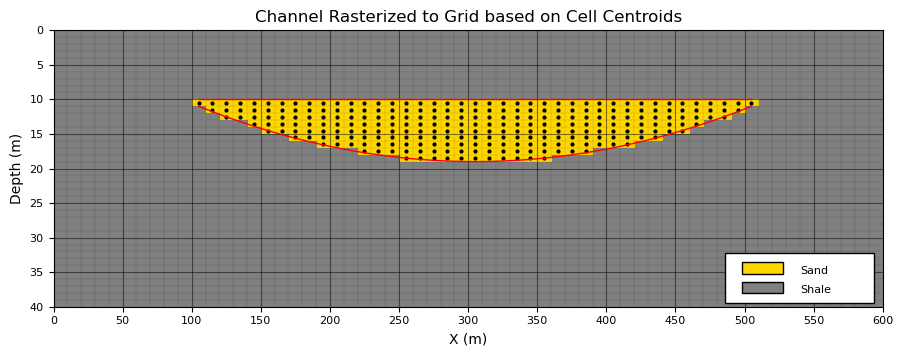

In [7]:
CH_ix = 30; CH_iy = 10                                        # channel location 

grid_test = np.zeros((ny, nx), dtype=int)                     # initialize single channel test model
fig = plt.figure(figsize=(10.7, 4)); ax = plt.gca()           # plot specs
grid_test = add_channel(grid_test,ix = CH_ix,iy=CH_iy,half_width=20,thickness=8,p=2) # make single channel model
add_model_grid(ax); add_custom_sand_shale_legend(ax)          # custom grid and legend
plt.imshow(grid_test,interpolation = None,aspect=5.0,cmap=cmap_facies_cont,extent=extents)  # plot model
plot_channel_centroids(ax,grid_test,xmn, ymn,xsiz, ysiz,c='k',s=4,marker='o')
plot_channel_outline(ax,CH_ix, CH_iy,half_width=20,thickness=8,xmn=xmn, ymn=ymn,xsiz=xsiz, ysiz=ysiz,p=2,color='r',lw=1)

plt.title("Channel Rasterized to Grid based on Cell Centroids"); plt.xlabel("X (m)"); plt.ylabel("Depth (m)"); plt.show()

Now let's vary the channel width ($CH_{width}$) and channel thickness ($CH_{thick}$) to visualize the associated change in channel geometry. 

Check for, 

* reasonable geometries - no discontinuities, unrealistic shapes

* parameterization reproduced for the rasterized model - rasterised objects in grid reproduce the input parameters

<figure style="text-align: center;">
  <img src="_static/object/check_channel_parameters.png" style="display: block; margin: 0 auto; width: 100%;">
  <figcaption style="text-align: center;"> Visual and check a variety of channel objects for reasonable geometries and parameters reproduced with the rastered objects.
</figcaption>
</figure>

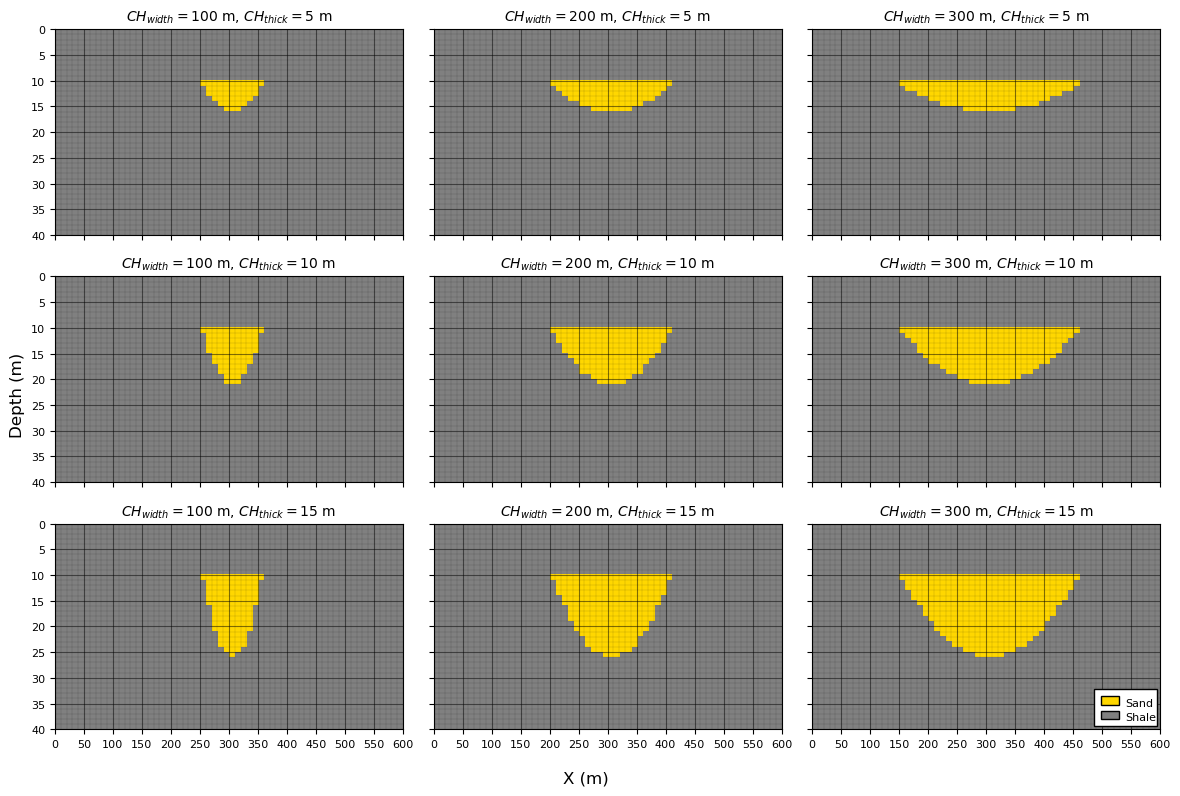

In [8]:
CH_ix = 30; CH_iy = 10                                        # channel location 

CHwidth_mat = np.array([100, 200, 300])
CHthick_mat = np.array([5, 10, 15])

iCH_half_width_mean = (CHwidth_mat*0.5/xsiz).astype(int); iCH_half_width_stdev = 0 # convert to half width in cells
iCH_thick_mean = (CHthick_mat/ysiz).astype(int); iCH_thick_stdev = 0 # convert to thickness in cells

fig, axes = plt.subplots(3, 3,figsize=(12, 8),sharex=True,sharey=True)

for i, CHthick in enumerate(CHthick_mat):                     # loop over channel widths and thicknesses
    for j, CHwidth in enumerate(CHwidth_mat):
        grid_test = np.zeros((ny, nx), dtype=int)             # initialize single channel test model
        ax = axes[i, j]
        grid_test = add_channel(grid_test,ix = CH_ix,iy=CH_iy,half_width=iCH_half_width_mean[j],
            thickness=iCH_half_width_mean[i],p=2) # make single channel model
        im = ax.imshow(grid_test,cmap=cmap_facies_cont,extent=extents,interpolation='nearest',aspect='auto')
        ax.set_title(rf"$CH_{{width}}={CHwidth}$ m, $CH_{{thick}}={CHthick}$ m",fontsize=10)
        add_model_grid(ax); ax.set_axisbelow(True)

add_custom_sand_shale_legend(axes[-1,-1])
fig.supxlabel("X (m)"); fig.supylabel("Depth (m)")
plt.tight_layout(); plt.show()

#### Unconditional Object-Based Models

To perform unconditional object-based simulation, we require three key ingredients:

* **a parameterized object geometry**  - in our example, each channel is defined by a channel width and channel thickness,

$$
\boldsymbol{\theta}_k =\{CH_{width}^{k},CH_{thick}^{k}\}
$$

* **probability distributions for each geometric parameter** - these distributions describe the uncertainty in channel width and channel thickness and are used to randomly generate channel geometries.

* **a target global object proportion** - that specifies the overall fraction of the model occupied by channels.

Before generating realizations, it is useful to examine each of these requirements in more detail.

##### Parameter Distributions

Object-based simulation is fundamentally a Monte Carlo simulation procedure. 

* each realization is generated by repeatedly drawing object parameters from probability distributions and placing the resulting objects within the model.

For realization $\ell$, the set of all simulated objects is,

$$
\mathcal{O}^{(\ell)}=\{\boldsymbol{\theta}_1^{(\ell)},\boldsymbol{\theta}_2^{(\ell)},\ldots,\boldsymbol{\theta}_{N^{(\ell)}}^{(\ell)} \},
$$

where $N^{(\ell)}$ is the number of objects in realization $\ell$ and,

$$
\boldsymbol{\theta}_k^{(\ell)}= \{CH_{width,k}^{(\ell)},CH_{thick,k}^{(\ell)}\}
$$

contains the geometric parameters of object $k$.

If object parameters are sampled independently from a common prior distribution $p(\boldsymbol{\theta})$, the probability density of the entire realization is,

$$
p\left(\mathcal{O}^{(\ell)}\right) = 
\prod_{k=1}^{N^{(\ell)}}
p\left(
\boldsymbol{\theta}_k^{(\ell)}
\right).
$$

Although the simulation is performed sequentially by placing one object at a time, the resulting realization can be viewed as a Monte Carlo sample drawn from this joint probability distribution.

This formulation makes several simplifying assumptions.

**Independent object sampling**

Each object's parameters are sampled independently of all previously placed objects. For example, a large channel may be followed by a small channel, or vice versa, without any dependence between them.

**Identical object priors (stationarity)**

The parameter distributions remain constant throughout the simulation. The statistical properties of channels do not systematically change from one object to the next.

**Independent realization construction**

The probability of a realization is represented as the product of the probabilities of the individual objects comprising that realization.

Therefore,

$$
p\left(\mathcal{O}^{(\ell)}\right)=\prod_{k=1}^{N^{(\ell)}}p\left(\boldsymbol{\theta}_k^{(\ell)}\right)
$$

is simply the joint probability density function of the object geometries that make up realization $\ell$.

The model described above is intentionally simple. Many practical object-based workflows relax one or more of these assumptions to represent more realistic geological behavior.

Examples include:

* **Nonstationary object parameters** — channel width and thickness may vary systematically throughout the model domain. During simulation, local parameter distributions are used to constrain object geometries.

* **Nonstationary object occurrence and orientation** — secondary information may indicate that channels are more common in certain regions or that preferred orientations vary spatially.

* **Dependence between object parameters** — geological dimensions are often correlated. For example, channel width and thickness may follow a width-to-thickness ratio ranging from approximately 10:1 to 30:1. In this case, one parameter may be simulated directly while the remaining parameter is assigned through the geological relationship.

These extensions allow object-based models to incorporate increasing levels of geological realism while retaining the intuitive object-based framework.

##### Global Proportions

The global channel proportion specifies the overall fraction of the model occupied by channels. During simulation, objects are added sequentially until this target proportion is achieved.

* this quantity plays a role analogous to the global mean in sequential Gaussian simulation or the global facies proportion in indicator simulation.

Estimating global proportions is often challenging because subsurface data are sparse and may be spatially biased. Consequently, careful integration of all available information sources is required, including,

* well observations,
* outcrop analogs,
* conceptual geological models,
* seismic interpretation, and
* spatial sample debiasing methods such as declustering.

Global proportions are also an important source of uncertainty. In practice, uncertainty management workflows frequently include multiple proportion scenarios, allowing decision-makers to evaluate the impact of alternative geological interpretations on model predictions.

For this chapter, we assume that the global channel proportion is known and use it as a stopping criterion during object placement. Objects are added sequentially until the desired channel proportion is reached.


#### Unconditional Object-Based Simulation

Unconditional object-based simulation is a sequential Monte Carlo procedure. Objects are repeatedly sampled from their parameter distributions and placed at random locations within the model until a target global proportion is reached.

The workflow consists of the following steps,

1. Monte Carlo simulate (MCS) an object's geometric parameters,

$$
\boldsymbol{\theta}_k^{(\ell)} = \{ CH_{width,k}^{(\ell)},CH_{thick,k}^{(\ell)} \}
$$

2. Monte Carlo simulate an object location,

$$
\mathbf{u}_k^{(\ell)} = 
(x_k^{(\ell)},y_k^{(\ell)}).
$$

3. Place the parameterized object,

$$
\boldsymbol{\theta}_k^{(\ell)}
\left(
\mathbf{u}_k^{(\ell)}
\right),
$$

at the sampled location and update the facies model.

4. Repeat Steps 1–3 until the target global channel proportion is exceeded.

The resulting realization is therefore a collection of randomly placed channel objects whose geometries are sampled from the specified parameter distributions.

For this demonstration, we generate unconditional realizations using the following parameter distributions,

$$
CH_{width}
\sim
N(200.0,60.0)
$$

and

$$
CH_{thick}
\sim
N(10.0,2.0)
$$

These distributions represent uncertainty in channel width and channel thickness and provide the variability required to generate multiple equally probable realizations.

Before generating realizations, it is useful to visualize the parameter distributions. This allows us to verify that the sampled object geometries are consistent with our geological interpretation and provides intuition for the range of channel shapes that may appear in the simulated models.


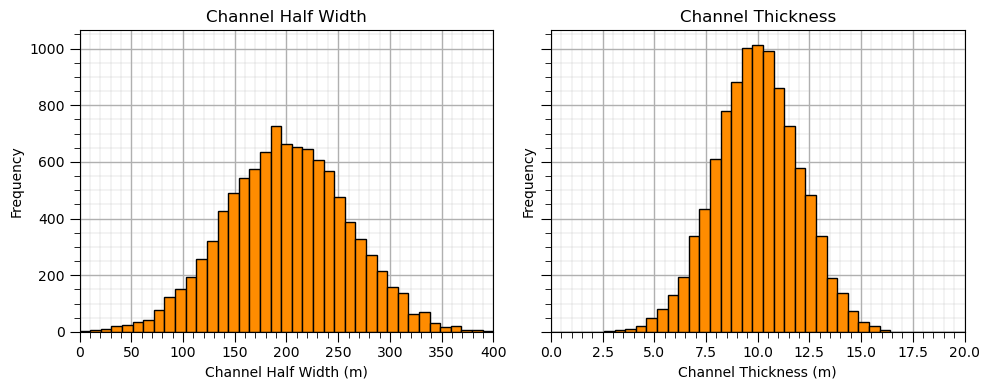

In [9]:
CH_width_mean = 200.0; CH_width_stdev = 60                    # set geometric parameters' distributions
CH_thick_mean = 10.0; CH_thick_stdev = 2.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)  # plot both as histograms

ax1 = plt.subplot(121)                      
ax1.hist(np.random.normal(loc=200.0,scale=60.0,size=10000),bins=np.linspace(0,400,40),color='darkorange',edgecolor='black')
add_grid2(ax1); ax1.set_xlabel('Channel Half Width (m)'); ax1.set_ylabel('Frequency'); ax1.set_title('Channel Half Width')
ax1.set_xlim([0,400])

ax2 = plt.subplot(122)
ax2.hist(np.random.normal(loc=10.0,scale=2.0,size=10000),bins=np.linspace(0,20.0,40),color='darkorange',edgecolor='black')
add_grid2(ax2); ax2.set_xlabel('Channel Thickness (m)'); ax2.set_ylabel('Frequency'); ax2.set_title('Channel Thickness')
ax2.set_xlim([0,20])

plt.tight_layout(); plt.show()

##### Effect of Random Number Seed

Object-based simulation is a stochastic process. Multiple equally probable realizations can be generated by changing the random number seed.

Each realization is generated from the same geological model,

* the same object geometry definitions

* the same parameter distributions

* the same global channel proportion

* the same simulation algorithm

However, changing the random seed produces different random draws of object parameters,

$$
\boldsymbol{\theta}_k^{(\ell)}=\{ CH_{width,k}^{(\ell)},CH_{thick,k}^{(\ell)} \},$$

and different object locations,

$$
\mathbf{u}_k^{(\ell)} = (x_k^{(\ell)},y_k^{(\ell)})
$$

Consequently, each realization contains a unique arrangement of channel objects,

$$
\boldsymbol{\theta}_k^{(\ell)} = \left(\mathbf{u}_k^{(\ell)}\right)$$

while remaining consistent with the same underlying geological assumptions.

This is an important concept in geostatistical simulation. We are not seeking a single "best" model. Instead, we generate multiple equiprobable realizations that collectively represent geological uncertainty.

To illustrate this concept, we generate and visualize six realizations using:

* a target channel proportion of 20%,

* identical channel parameter distributions, and

* different random number seeds.

Observe that each realization contains different channel geometries and locations, yet all realizations exhibit similar overall geological characteristics.

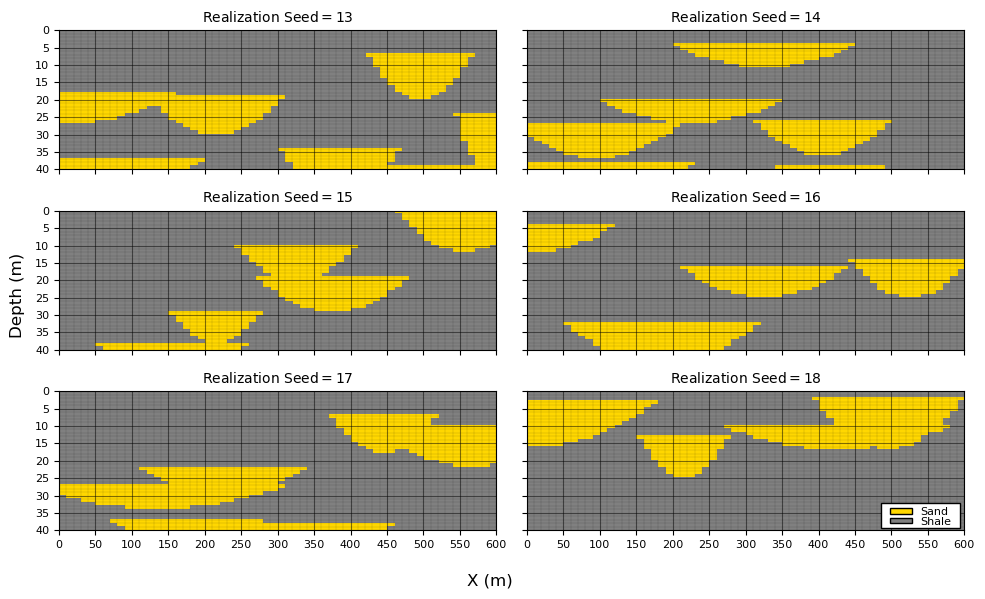

In [10]:
seeds = [13, 14, 15, 16, 17, 18]                              # set the random number seeds

CH_width_mean = 200.0; CH_width_stdev = 60                    # geometric parameter distributions (Gaussian)
CH_thick_mean = 10.0; CH_thick_stdev = 2.0

iCH_half_width_mean = int(CH_width_mean*0.5/xsiz); iCH_half_width_stdev = int(CH_width_stdev*0.5/xsiz) # convert to half width in cells
iCH_thick_mean = int(CH_thick_mean/ysiz); iCH_thick_stdev = int(CH_thick_stdev/ysiz) # convert to thickness in cells

fig, axes = plt.subplots(3, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, seed in zip(axes, seeds):                             # loop over random number seeds
    grid = generate_model(nx, ny, CHprop=0.20,CHwidth = [iCH_half_width_mean,iCH_half_width_stdev], # calculate unconditional simulation
        CHthick = [iCH_thick_mean,iCH_thick_stdev],seed=seed,p=2)
    im = ax.imshow(grid,cmap=cmap_facies_cont,extent=extents,interpolation='nearest',aspect='auto')
    ax.set_title(rf"Realization $\mathrm{{Seed}} ={seed:.0f}\,$",fontsize=10)
    add_model_grid(ax)    
    ax.set_axisbelow(True)

add_custom_sand_shale_legend(axes[-1])                        # add a facies legend to the last plot
fig.supxlabel("X (m)"); fig.supylabel("Depth (m)")

plt.tight_layout(); plt.show()

##### Effect of Global Channel Proportion

In the previous examples, we used a channel proportion of 20%. This relatively low proportion was selected so that individual channels remain visually distinct and easy to interpret.

As channel proportion increases, object-based simulation must place additional channels within the same model volume. Because object locations are sampled randomly, the model increasingly relies on channel overlap (amalgamation) to achieve the target proportion.

Consequently:

* low channel proportions tend to produce isolated channel bodies,

* intermediate proportions produce increased channel connectivity and overlap,

* high proportions often result in extensive channel amalgamation and connected channel complexes.

For simple object-based models with random object placement, high channel proportions can only be achieved by placing many overlapping channels. This behavior is not necessarily unrealistic—in many depositional environments channel amalgamation is common—but it is important to recognize that the resulting connectivity arises primarily from the simulation methodology rather than from explicit geological rules.

To illustrate this effect, we generate realizations with a range of global channel proportions,

$$
CH_{prop}=[10\%,20\%,,30\%,,40\%,,50\%,,60\%]
$$

All other model settings are held constant, including the channel geometry distributions,

$$
CH_{width}
\sim
N(200.0,60.0),
$$

and,

$$
CH_{thick}
\sim
N(10.0,0.2).
$$

By varying only the global channel proportion, we can directly observe how increasing facies proportion influences channel connectivity, overlap, and the resulting geological architecture.

As you examine the realizations below, notice how the channels evolve from isolated bodies at low proportions to increasingly amalgamated channel complexes at high proportions. 

* this transition highlights one of the key controls on object-based simulation outcomes: the interaction between object geometry and global facies proportion.

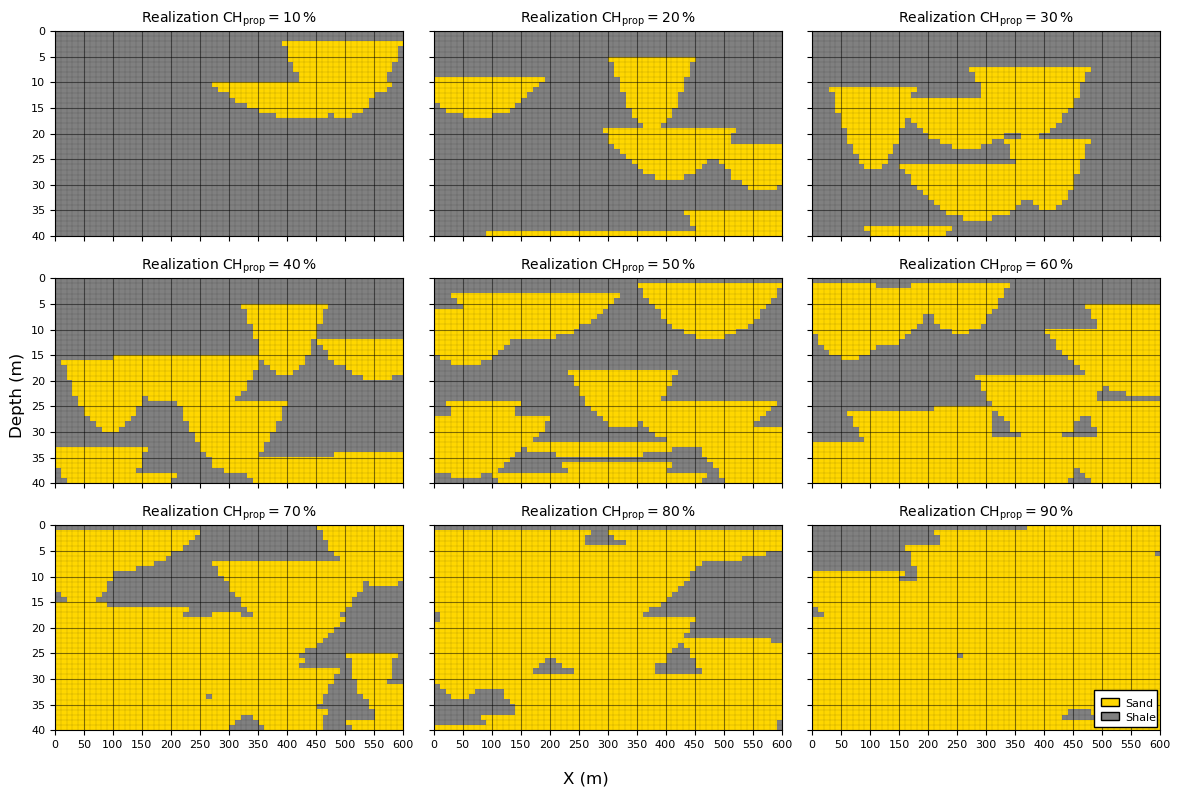

In [11]:
CHprop_mat = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]            # specify the channel proportions         

CH_width_mean = 200.0; CH_width_stdev = 60                    # geometric parameter distributions (Gaussian)
CH_thick_mean = 10.0; CH_thick_stdev = 2.0

iCH_half_width_mean = int(CH_width_mean*0.5/xsiz); iCH_half_width_stdev = int(CH_width_stdev*0.5/xsiz) # convert to half width in cells
iCH_thick_mean = int(CH_thick_mean/ysiz); iCH_thick_stdev = int(CH_thick_stdev/ysiz) # convert to thickness in cells

fig, axes = plt.subplots(3, 3,figsize=(12, 8),sharex=True,sharey=True)

k = 0
for i in range(0,3):                                          # loop over channel proportions                
    for j in range(0,3):
        ax = axes[i, j]
        grid = generate_model(nx, ny, CHprop=CHprop_mat[k],   # calculate unconditional simulation
            CHwidth = [iCH_half_width_mean,iCH_half_width_stdev],CHthick = [iCH_thick_mean,iCH_thick_stdev],seed=seed+i*3+j,p=2)
        im = ax.imshow(grid,cmap=cmap_facies_cont,extent=extents,interpolation='nearest',aspect='auto')
        ax.set_title(rf"Realization $\mathrm{{CH}}_{{\mathrm{{prop}}}}={CHprop_mat[k]*100:.0f}\,\%$",fontsize=10)
        add_model_grid(ax)    
        ax.set_axisbelow(True)
        k = k + 1

add_custom_sand_shale_legend(axes[-1,-1])
fig.supxlabel("X (m)"); fig.supylabel("Depth (m)")
plt.tight_layout(); plt.show()

At 70% or higher channel proportion it is difficult to visualize the channel geometries,

* the models is almagamated channel sand with some remenants of overbank shale.

##### Effect of Channel Geometries

In the previous examples, the channel geometry distributions were held constant. In practice, however, channel dimensions are often uncertain and may be incorporated into the uncertainty management plan through multiple geometric scenarios.

* for example, different geological interpretations, analog datasets, or depositional concepts may suggest different channel widths and thicknesses.

Object-based simulation provides a straightforward framework for evaluating the impact of these alternative geometric models.

When global channel proportion is held constant, channel geometry has a significant influence on the resulting spatial architecture,

* Small channel geometries require a larger number of channels to achieve the target proportion, resulting in more fragmented and tortuous channel networks.

* Large channel geometries require fewer channels to achieve the same target proportion, producing larger connected channel bodies and compartments.

* Larger channels also increase the likelihood of channel overlap and amalgamation, potentially creating highly connected channel systems.

To illustrate these effects, we generate realizations using a range of channel geometries,

* $CH_{width} = [100,200,300]$ m

* $CH_{thick} = [5,10,15]$ m

while maintaining the same global channel proportion.

To simplify the comparison, the standard deviation of both geometric parameters is set to zero for each scenario. Therefore, although channel dimensions vary between scenarios, all channels within a given realization have identical geometries.

This allows us to isolate the effect of channel size on the simulated architecture. 

* any differences observed between realizations arise solely from changes in the channel geometry and not from within-scenario geometric variability.

As you examine the realizations below, notice how increasing channel dimensions transforms the model from one containing many small channel bodies to one dominated by fewer, larger channel complexes. This sensitivity to object geometry is one of the defining characteristics of object-based simulation.

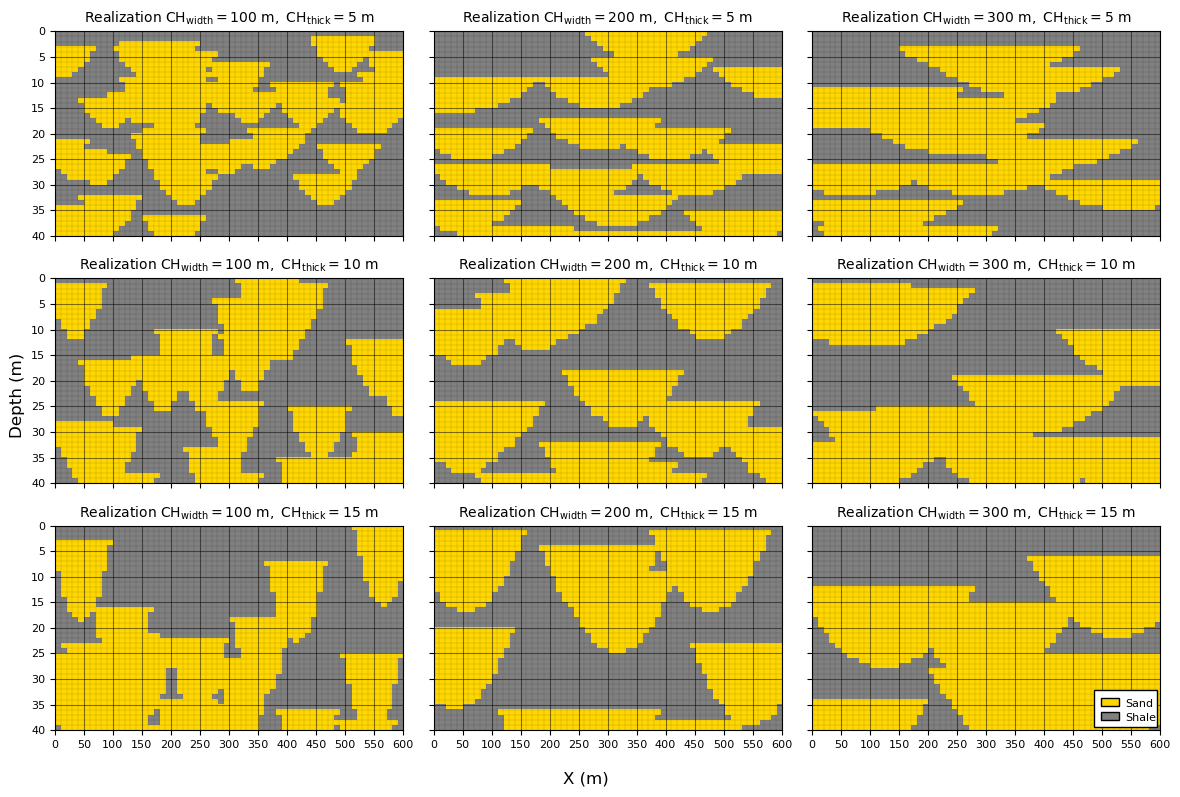

In [12]:
CHprop = 0.50                                                 # specify the channel porportion
CHwidth_mat = [100, 200, 300]                           # geometric parameter distributions (constant)
CHthick_mat = [5, 10, 15]
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization and wrapper
fig, axes = plt.subplots(3, 3,figsize=(12, 8),sharex=True,sharey=True)

for i, CHthick in enumerate(CHthick_mat):                     # loop over channel geometries
    for j, CHwidth in enumerate(CHwidth_mat):

        iCH_half_width_mean = int(CHwidth_mat[j]*0.5/xsiz)    # convert to half width in cells
        iCH_thick_mean = int(CHthick_mat[i]/ysiz)             # convert to thickness in cells
        
        ax = axes[i, j]
        grid = generate_model(nx, ny, CHprop=CHprop,CHwidth = [iCH_half_width_mean,0.0], # calculate unconditional simulation
            CHthick = [iCH_thick_mean,0.0],seed=seed+i*3+j,p=2)
        im = ax.imshow(grid,cmap=cmap_facies_cont,extent=extents,interpolation='nearest',aspect='auto')
        ax.set_title(rf"Realization $\mathrm{{CH}}_{{\mathrm{{width}}}}={CHwidth_mat[j]}\ \mathrm{{m}},\ "
            rf"\mathrm{{CH}}_{{\mathrm{{thick}}}}={CHthick_mat[i]}\ \mathrm{{m}}$",fontsize=10)
        add_model_grid(ax)    
        ax.set_axisbelow(True)

add_custom_sand_shale_legend(axes[-1,-1])
fig.supxlabel("X (m)"); fig.supylabel("Depth (m)")
plt.tight_layout(); plt.show()

##### Observations on Unconditional Object-Based Simulation

From the previous examples, it should be apparent that the key object-based model parameters are not independent of one another. The resulting geological architecture is controlled by the interaction between,

* channel geometric parameters, $CH_{width}$ and $CH_{thick}$,

* global channel proportion, $CH_{prop}$, and

* the number of simulated channels, $n_{CH}$.

Although the number of channels is not typically specified directly as an input parameter, it emerges naturally as an outcome of the simulation process.

For example,

* at a fixed channel proportion, larger channels require fewer objects to achieve the target proportion.

* at a fixed channel proportion, smaller channels require more objects to achieve the target proportion.

* at a fixed channel geometry, increasing the channel proportion requires additional channel placement, increasing the likelihood of overlap and amalgamation.

Therefore, channel geometry, channel proportion, and channel count should be viewed as coupled characteristics of the object-based model rather than independent controls.

Another practical consideration is the accuracy with which the target channel proportion is reproduced. 

* most object-based simulation algorithms terminate once the target proportion is exceeded.

Consequently, the precision of the final proportion depends on the size of the objects being added.

* for large objects, a single additional channel may contribute a substantial proportion of the model volume, causing the final realization to overshoot the target proportion.

* in contrast, smaller objects provide finer control over the final proportion because each object contributes a smaller increment.

A common refinement is to terminate the simulation when the target proportion lies within one additional object's contribution. In other words, before placing the next channel, the algorithm evaluates whether doing so would move the realization farther from the target proportion than stopping immediately.

* implementing this strategy requires tracking the incremental proportion contributed by each newly placed object and comparing the resulting proportion against the target value.

For simplicity, our demonstration implementation does not include this refinement. Instead, channels are added sequentially until the target proportion is exceeded. While this approach is sufficient for illustrating the fundamental concepts of object-based simulation, more sophisticated implementations often include additional controls to improve proportion matching and computational efficiency.

At this point, we have developed a complete unconditional object-based simulation workflow,

* define object geometries

* specify parameter distributions

* sample object locations

* sequentially place objects until the target proportion is achieved.

In the next section, we extend this framework to incorporate conditioning data, allowing object placement to honor observations from wells and other sources of geological information.

#### Build a Well Dataset

To demonstrate conditional object-based simulation, we first require conditioning data.

* for simplicity, we construct a synthetic dataset by extracting an exhaustively sampled vertical well from the center of the model domain.

Rather than generating the well data independently, we first simulate a complete unconditional object-based realization and then sample the well directly from the model grid. 

* this approach ensures that the conditioning data are spatially consistent with the geological model being used for simulation.

Using this workflow provides several advantages,

* the well will contain approximately the same channel proportion as the surrounding model (subject to expected sampling fluctuations).

* the observed thicknesses of channel and background facies will be consistent with the object geometries used during simulation.

* if multiple wells are extracted, the spatial relationships between wells will be consistent with the channel architecture represented in the model.

* the conditioning data will be free of contradictions that could arise if the well observations were generated independently of the simulation model.

This approach is common when developing and testing geostatistical algorithms because it provides a controlled environment in which the "true" model is known. Any differences between the conditional realizations and the original model can therefore be attributed to uncertainty arising from limited data rather than inconsistencies in the dataset itself.

The workflow is straightforward,

1. Generate an unconditional object-based realization.

2. Select one or more well locations.

3. Extract the facies values along the well trajectories.

4. Store the sampled values as conditioning data.

The resulting well dataset represents the information that would be available from subsurface observations, while the original realization serves as the unknown geological truth that we seek to reproduce through conditional simulation.

In the example below, we extract a single vertical well from the center of the model. The well is exhaustively sampled, meaning that every model layer intersected by the well is observed and assigned a facies value.

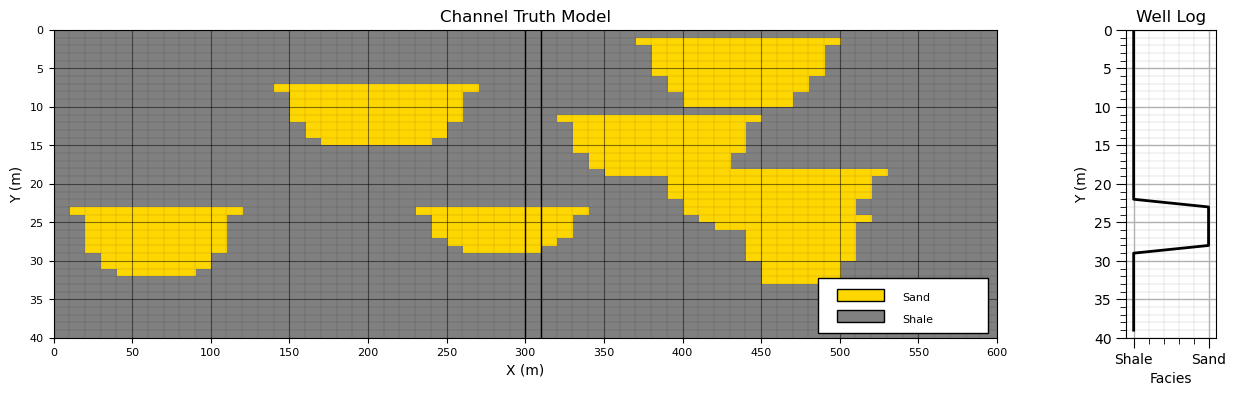

In [13]:
ix_well = 30                                                  # specify the well location    

grid, well, mask = generate_channel_well_data(nx=nx,ny=ny,xsiz=xsiz,ysiz=ysiz,ix=ix_well,CHprop=0.2,seed=42) # calculate well data

well_grid = build_well_as_full_grid(grid, ix_well)            # convert well vector to 2D ndarray

y = np.arange(ny) * ysiz                                      # calculate depth scale for plotting the well log

fig = plt.figure(figsize=(15, 4))

gs = fig.add_gridspec(1, 2, width_ratios=[10.5, 1.0], wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])   # wide geology panel
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)  # narrow well log

im = ax1.imshow(grid,cmap=cmap_facies_cont,extent=extents,aspect='auto') # plot 2D model

ax1.axvline(ix_well * xsiz, color='black', linewidth=1)        # indentify well location
ax1.axvline(ix_well * xsiz + xsiz, color='black', linewidth=1)

ax1.set_title("Channel Truth Model"); ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)"); add_model_grid(ax1); add_custom_sand_shale_legend(ax1)

ax2.plot(well, y, color='black', linewidth=2)       # plot well log
ax2.set_title("Well Log"); ax2.set_xlabel("Facies"); ax2.set_xlim(-0.1, 1.1)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Shale", "Sand"]); add_grid2(ax2); ax2.set_ylabel("Y (m)")

plt.tight_layout(); plt.show()

To illustrate conditional object-based simulation, we begin by showing the underlying “truth” model together with the extracted well data. The truth model represents the full unconditional realization from which the conditioning data are sampled.

We then isolate the well data and remove the remainder of the model.

From this point forward, we assume that only the well observations are available,

* the full realization (the “truth” model) is discarded,

* the well data are retained as conditioning information,

* and the original spatial distribution of facies is treated as unknown.

This is an important conceptual step in geostatistical modeling, in real subsurface applications, we never have access to the full geological realization. Instead, we only observe sparse, incomplete data such as wells, and must reconstruct plausible geological scenarios that are consistent with those observations.

Thus, going forward, we will work exclusively with the well dataset,

* we retain only the well,

* and discard the remainder of the model.

This sets up the conditional simulation problem, generating multiple realizations that honor sparse well data while remaining consistent with the object-based geological model.

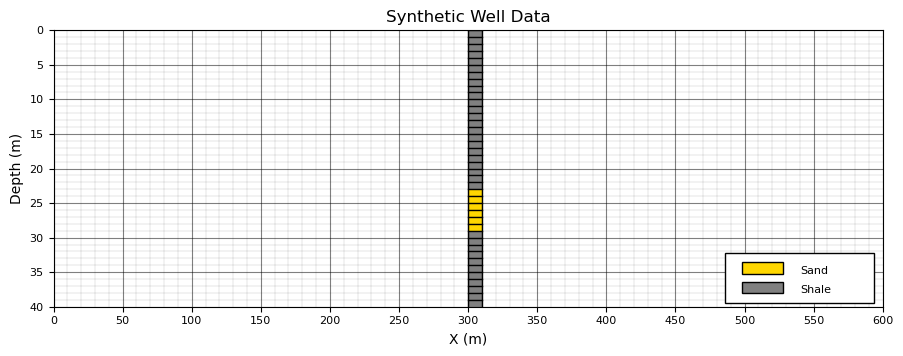

In [14]:
fig = plt.figure(figsize=(10.7, 4))
  
plt.imshow(well_grid,interpolation = None,aspect=5.0,cmap=cmap_facies_cont,extent=extents) # plot well data in grid
ax = plt.gca()
wellxmin = ix_well * xsiz; wellxmax = ix_well * xsiz + xsiz   # calculate edges of well column in grid
plt.axvline(wellxmin, color='black', lw=1); plt.axvline(wellxmax, color='black', lw=1)
for iy in range(0,ny):                                        # plot horizontal borders of well column in grid
    plt.plot([wellxmin,wellxmax],[iy * ysiz,iy * ysiz],color='black',lw=1)

add_model_grid(ax); add_custom_sand_shale_legend(ax)          # add grid lines and legend

plt.title("Synthetic Well Data"); plt.xlabel("X (m)"); plt.ylabel("Depth (m)"); plt.show()

#### Conditional Object-Based Simulation

Conditional object-based simulation extends the unconditional framework by incorporating conditioning data (e.g., well observations) into the object placement process.

We begin by recalling the unconditional simulation workflow,

1. Monte Carlo sample object parameters,

$$
\boldsymbol{\theta}_k^{(\ell)}=\{ CH_{width,k}^{(\ell)}, CH_{thick,k}^{(\ell)} \},
$$

2. Monte Carlo sample an object location,

$$
\mathbf{u}_k^{(\ell)} = (x_k^{(\ell)}, y_k^{(\ell)}),
$$

3. Place the object at the sampled location, forming a facies contribution

$$
\boldsymbol{\theta}_k^{(\ell)}\left(\mathbf{u}_k^{(\ell)}\right),
$$

4. Repeat until the target global channel proportion is reached.

##### Rejection Sampling Interpretation

In theory, one could generate unconditional realizations and retain only those that match the conditioning data. 

* this corresponds to a rejection sampling approach.

While conceptually straightforward and free of algorithmic bias, this strategy is not practical for object-based models. For most realistic datasets, the probability of randomly generating a realization that exactly matches sparse conditioning data is extremely small. 

* in practice, this would require an infeasible number of simulations.

##### Practical Conditional Object-Based Simulation

Instead, most practical implementations use a two-stage heuristic approach,

1. **Data conditioning stage** - explicitly place objects so that they honor observed facies intervals in wells.

2. **Background simulation stage** - populate the remainder of the model with stochastic objects while avoiding conflicts with conditioning data and maintaining the target global proportion.

This strategy preserves computational efficiency while enforcing hard data constraints.

##### 1. Object Placement at Conditioning Data

The first stage ensures that the model reproduces observed facies along wells. A typical workflow is,

1. Sample an initial object geometry from the geometric parameter distributions.

2. Match object placement to observed channel intervals in the well (e.g., align object tops with observed sand intervals).

3. Adjust lateral position of the object to ensure consistency with both sand and shale observations along the well trajectory.

4. Repeat until all observed channel intervals are represented by at least one object.

This stage ensures that conditioning data are honored exactly (hard data conditioning).

##### 2. Stochastic Placement Away from Data

The second stage fills the remaining model domain while preserving consistency with the conditioning data,

1. Sample object parameters,

$$
\boldsymbol{\theta}_k^{(\ell)}
$$

2. Sample a location,

$$
\mathbf{u}_k^{(\ell)}
$$

3. Reject the object if it intersects conditioning data in an inconsistent way.

4. Otherwise, place the object in the model.

5. Repeat until the target global channel proportion is reached.

This stage ensures that the overall facies proportion and spatial variability are maintained while respecting hard data constraints.

##### Limitations of Conditional Object-Based Simulation

Despite its practicality, conditional object-based simulation has several well-known limitations,

* **Scale mismatch** - conditioning becomes increasingly difficult when object dimensions are large relative to data spacing. In such cases, a single object may not be able to simultaneously honor multiple nearby observations.

* **Inconsistent parameterization** - conditioning data and object parameter distributions may be incompatible, making exact conditioning impossible without distortion.

* **Artifacts from heuristic placement** - the two-stage approach may introduce systematic biases. For example, channels may appear artificially constrained near wells and more variable away from data.

A desirable property of a well-designed conditional object-based model is *data invisibility*: if conditioning data are removed, their locations should not be inferable from the resulting realizations.

To demonstrate these concepts, we generate six conditional realizations using,

$$
CH_{width} \sim \mathcal{N}(200.0, 60.0),
$$

$$
CH_{thick} \sim \mathcal{N}(10.0, 0.2),
$$

with a target channel proportion of 20%.

The resulting realizations illustrate how conditioning influences object placement while maintaining consistency with the underlying stochastic geological model.

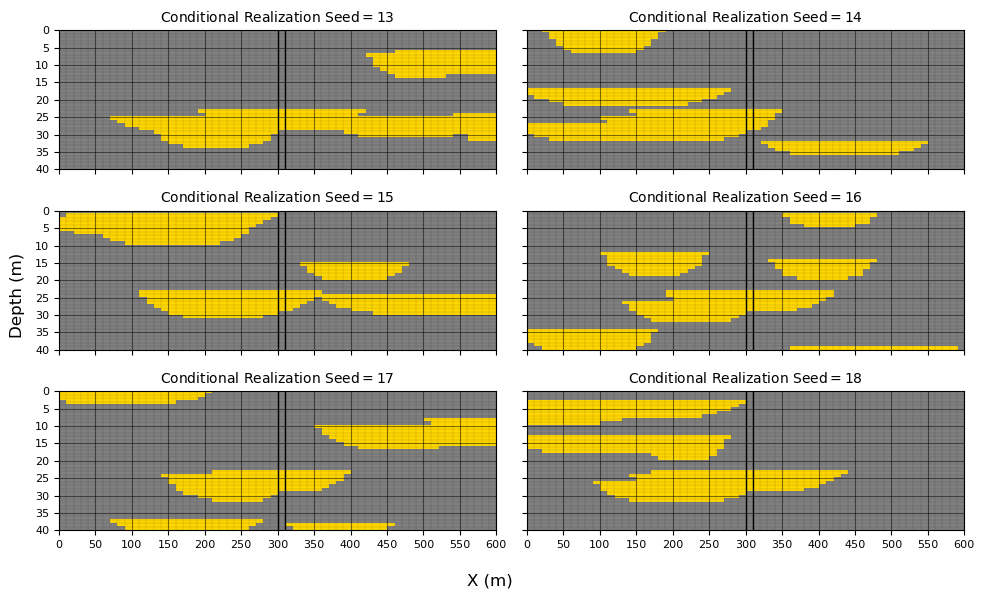

In [15]:
seeds = [13, 14, 15, 16, 17, 18]                              # specify random number seeds

CH_width_mean = 200.0; CH_width_stdev = 60                    # geometric parameter distributions (Gaussian)
CH_thick_mean = 5.0; CH_thick_stdev = 1.0

iCH_half_width_mean = int(CH_width_mean*0.5/xsiz); iCH_half_width_stdev = int(CH_width_stdev*0.5/xsiz) # convert to half width in cells
iCH_thick_mean = int(CH_thick_mean/ysiz); iCH_thick_stdev = int(CH_thick_stdev/ysiz) # convert to thickness in cells

fig, axes = plt.subplots(3, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, seed in zip(axes, seeds):                              # loop over random number seeds
    sim = generate_conditional_model(nx, ny, CHprop=0.2,CHwidth = [iCH_half_width_mean,iCH_half_width_stdev], # calculate conditional simulation
        CHthick = [iCH_thick_mean,iCH_thick_stdev],well_grid=well_grid,ix_well=ix_well,seed=seed,max_iter=5000)
    im = ax.imshow(sim,cmap=cmap_facies_cont,extent=extents,interpolation='nearest',aspect='auto')
    ax.set_title(rf"Conditional Realization $\mathrm{{Seed}} ={seed:.0f}\,$",fontsize=10)
    wellxmin = ix_well * xsiz; wellxmax = ix_well * xsiz + xsiz
    ax.axvline(wellxmin, color='black', lw=1); ax.axvline(wellxmax, color='black', lw=1)
    add_model_grid(ax); ax.set_axisbelow(True)

ax = axes[-1]
fig.supxlabel("X (m)"); fig.supylabel("Depth (m)")
plt.tight_layout(); plt.show()

#### Check for Object-Based Conditional Artifacts

At first glance, the conditional realizations appear reasonable. All models honor the well data exactly,

* conditioning intervals at the wells are matched with no misclassification,

* channel geometries away from the wells remain visually consistent with the unconditional model.

However, visual inspection alone is not sufficient to evaluate whether the conditioning procedure has introduced subtle biases or artifacts.

In particular, conditional object-based methods are known to potentially distort spatial statistics near conditioning data. These effects are often not obvious in individual realizations.

* to investigate this, we move beyond qualitative inspection and compute ensemble statistics over a large number of realizations.

* specifically, we generate 100 conditional realizations and evaluate the local channel proportion at each grid cell.

This allows us to assess whether conditioning has introduced systematic spatial bias in the simulated facies distribution.

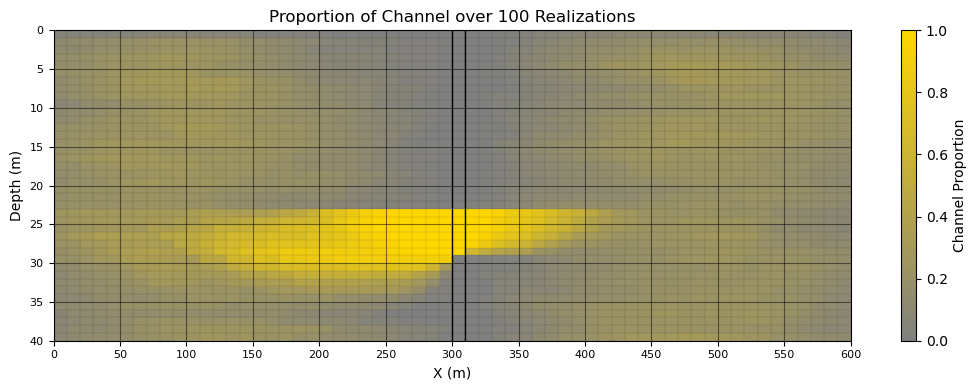

In [16]:
CH_width_mean = 200.0; CH_width_stdev = 60                    # geometric parameter distributions (Gaussian)
CH_thick_mean = 5.0; CH_thick_stdev = 1.0
seeds = [13, 14, 15, 16, 17, 18]                              # specify random number seeds

iCH_half_width_mean = int(CH_width_mean*0.5/xsiz); iCH_half_width_stdev = int(CH_width_stdev*0.5/xsiz) # convert to half width in cells
iCH_thick_mean = int(CH_thick_mean/ysiz); iCH_thick_stdev = int(CH_thick_stdev/ysiz) # convert to thickness in cells

L = 100
sims = np.zeros((L, ny, nx), dtype=np.uint8)                  # desclare 3D ndarray to store all realizations

for l in range(L):
    sims[l] = generate_conditional_model(nx, ny,CHprop=0.2,CHwidth=[iCH_half_width_mean, iCH_half_width_stdev],
        CHthick=[iCH_thick_mean, iCH_thick_stdev],well_grid=well_grid,ix_well=ix_well,seed=l,max_iter=5000)

P_channel = np.mean(sims == 1, axis=0)                        # probability/proportion of channel at each location

fig = plt.figure(figsize=(10.7, 4))
ax = plt.gca()
im = ax.imshow(P_channel,cmap=cmap_facies_cont,extent=extents,origin='upper',vmin=0,vmax=1,aspect='auto') # plot proportion over realizations
ax.set_title(f"Channel Proportion ({L} Realizations)")
add_model_grid(ax)

wellxmin = ix_well * xsiz; wellxmax = ix_well * xsiz + xsiz   # plot well location
ax.axvline(wellxmin, color='black', lw=1); ax.axvline(wellxmax, color='black', lw=1)

cbar = plt.colorbar(im, ax=ax); cbar.set_label("Channel Proportion")
plt.title("Proportion of Channel over " + str(L) + " Realizations"); 
plt.xlabel("X (m)"); plt.ylabel("Depth (m)")

plt.tight_layout(); plt.show()

The results of the ensemble analysis provide useful insight into the behavior of the conditional object-based simulation.

On the positive side,

* the channel proportion reaches 1.0 within the channel interval and 0.0 within the shale interval, confirming that the conditioning data are honored exactly. This indicates that the data-conditioning stage is functioning correctly.

* the transition in channel proportion from high values near channel intervals to low values near shale intervals is physically consistent and reflects the expected influence of conditioning data on nearby object placement.

However, several features of the result warrant further attention:

* there appears to be asymmetry in the channel proportion near the conditioned interval, suggesting a possible directional bias in object placement (e.g., preferential positioning of channel geometry relative to the conditioning constraint). This should be investigated further to determine whether it is a true algorithmic artifact or a consequence of model setup.

* The very low channel proportion in the top grid row of the domain indicates that channels rarely intersect the top boundary. This may be a direct consequence of the object generation rules (e.g., boundary handling or truncation logic) and should be verified against the intended simulation settings.

These observations highlight an important general principle, conditional object-based simulation can reproduce conditioning data exactly while still introducing subtle structural biases in the spatial statistics of the model.


#### Comments

This section provided a basic demonstration of object-based simulation for a binary channel–overbank system. At the time of writing, a full object-based simulation module is not yet included in GeostatsPy, but this will be improved and added in a future update.

The emphasis here has intentionally been on simplicity to clearly illustrate the core concepts of object-based modeling. Many additional complexities and enhancements are possible, and in practice, object-based simulation can become quite sophisticated. It is a modeling approach that I personally find both useful and enjoyable to work with.

Overall, I am satisfied with this demonstration, and I hope it helps build intuition for how object-based simulation works in practice.

If you are interested in additional geostatistical workflows and modeling demonstrations, you can find more examples in the GeostatsPy Demos repository:

https://github.com/GeostatsGuy/GeostatsPy_Demos/tree/main

I hope this was helpful.

*Michael*

#### About the Author

<figure style="text-align: center;">
  <img src="_static/intro/michael_pyrcz_officeshot_jacket.jpg" style="display: block; margin: 0 auto; width: 70%;">
  <figcaption style="text-align: center;"> Professor Michael Pyrcz in his office on the 40 acres, campus of The University of Texas at Austin.
</figcaption>
</figure>

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 90 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)